# Step 06 — Manuscript Submission Readiness and Archive Audit

This lightweight, artifact-only phase verifies the sealed Step 05 research package, maps major manuscript claims to evidence, inventories the completed Part 2 archive, and identifies human or venue-specific work still required before submission.

## Immutable boundary

- No training, model loading, inference, threshold search, or policy change.
- No test image, mask, NIfTI, PNG, loader, or source-dataset access.
- The completed Step 04 ledger remains sealed and prohibits rerun.
- Inputs are restricted to Part 2 documentation and generated artifacts from Steps 01–05.
- All Step 06 results are written only to this phase's `outputs/` directory.

`DIAGNOSTIC_COMPLETE` means the readiness audit completed. It does **not** mean the manuscript is submission-ready.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib, json, re
import pandas as pd
import matplotlib.pyplot as plt

STEP_DIR = Path.cwd().resolve()
if STEP_DIR.name != "step_06_manuscript_submission_readiness_and_archive":
    candidate = STEP_DIR / "step_06_manuscript_submission_readiness_and_archive"
    if candidate.is_dir(): STEP_DIR = candidate.resolve()
PART2 = STEP_DIR.parent
S5 = PART2 / "step_05_final_research_package" / "outputs"
S4 = PART2 / "step_04_one_time_locked_test_evaluation_after_explicit_authorization" / "outputs"
OUT = STEP_DIR / "outputs"; OUT.mkdir(parents=True, exist_ok=True)

MANIFEST_SHA256 = "575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63c1bfc6c2c615861889"
EXPECTED_RUN_ID = "871d289b-bf6b-4346-978f-2df02ade26ab"
CREATED_UTC = datetime.now(timezone.utc).isoformat()

def sha256(path):
    h=hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(lambda:f.read(1024*1024),b""): h.update(block)
    return h.hexdigest()
def load_json(path):
    with Path(path).open("r",encoding="utf-8") as f: return json.load(f)
def save_json(obj,name):
    p=OUT/name; p.write_text(json.dumps(obj,indent=2,sort_keys=True),encoding="utf-8"); return p
def save_csv(df,name):
    p=OUT/name; df.to_csv(p,index=False); return p

print("Step directory:", STEP_DIR)
print("Artifact-only boundary active; test source paths are not defined.")

Step directory: D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\mark 1 (part 2)\step_06_manuscript_submission_readiness_and_archive
Artifact-only boundary active; test source paths are not defined.


## 1. Sealed-package verification

Verify the final package gate and signature, the one-time test ledger, required Step 05 deliverables, manifest identity, and the explicit no-rerun/no-source-reopen state.

In [2]:
s5_gate=load_json(S5/"gate_result.json")
s5_sig=load_json(S5/"final_package_signature.json")
s4_gate=load_json(S4/"gate_result.json")
ledger=load_json(S4/"run_ledger.json")

checks=[
 ("step05_result_level",s5_gate.get("result_level")=="FINAL_PROJECT_COMPLETE",s5_gate.get("result_level")),
 ("step05_package_targets",bool(s5_gate.get("all_mandatory_targets_passed")),s5_gate.get("all_mandatory_targets_passed")),
 ("formal_failure_preserved",s5_gate.get("formal_model_acceptance_passed") is False,s5_gate.get("formal_model_acceptance_passed")),
 ("manifest_hash",s5_gate.get("manifest_sha256")==MANIFEST_SHA256,s5_gate.get("manifest_sha256")),
 ("test_inference_not_rerun",s5_sig.get("test_inference_rerun") is False,s5_sig.get("test_inference_rerun")),
 ("test_sources_not_reopened",s5_sig.get("test_source_files_reopened") is False,s5_sig.get("test_source_files_reopened")),
 ("sealed_run_id",s5_sig.get("source_test_run_id")==EXPECTED_RUN_ID,s5_sig.get("source_test_run_id")),
 ("ledger_complete",str(ledger.get("status","")).upper()=="COMPLETE",ledger.get("status")),
 ("ledger_rerun_prohibited",ledger.get("rerun_allowed") is False,ledger.get("rerun_allowed")),
 ("step04_result_level",s4_gate.get("result_level")=="FINAL_TEST_COMPLETE",s4_gate.get("result_level")),
]
required_s5=["FINAL_TECHNICAL_REPORT.md","PAPER_DRAFT.md","LIMITATIONS_AND_FAILURE_ANALYSIS.md",
 "REPRODUCIBILITY_INSTRUCTIONS.md","FINAL_PROJECT_DATA_CARD.md","ARTIFACT_CHECKSUM_INVENTORY.csv",
 "final_outcome_dashboard.png","patient_failure_distribution.png","validation_to_test_comparison.png"]
checks.extend((f"step05_output:{name}",(S5/name).is_file(),str(S5/name)) for name in required_s5)
verification=pd.DataFrame(checks,columns=["check","passed","observed"])
save_csv(verification,"final_package_verification.csv")
assert verification.passed.all(), verification.loc[~verification.passed].to_dict("records")
print(f"PASS: {verification.passed.sum()}/{len(verification)} sealed-package checks")

PASS: 19/19 sealed-package checks


## 2. Manuscript content and evidence traceability

The checklist separates scientific completeness from external/manual submission requirements. It does not invent venue rules or literature citations.

In [3]:
paper_path=S5/"PAPER_DRAFT.md"; report_path=S5/"FINAL_TECHNICAL_REPORT.md"
paper=paper_path.read_text(encoding="utf-8")
report=report_path.read_text(encoding="utf-8")

items=[
 ("scientific_content","Descriptive title",paper.startswith("# "),True,"Present in draft"),
 ("scientific_content","Structured abstract",all(x in paper for x in ["**Background:**","**Methods:**","**Results:**","**Conclusion:**"]),True,"Present in draft"),
 ("scientific_content","Introduction","## 1. Introduction" in paper,True,"Present in draft"),
 ("scientific_content","Dataset governance","### 2.1 Dataset governance" in paper,True,"Manifest-locked governance described"),
 ("scientific_content","Model and inference policy","### 2.3 Tumour models and fusion" in paper,True,"Frozen maximum-fusion policy described"),
 ("scientific_content","Uncertainty and metrics","### 2.4 Outcomes and uncertainty" in paper,True,"Patient bootstrap and metrics described"),
 ("scientific_content","One-time test governance","### 2.5 Governance and test lock" in paper,True,"Run UUID and no-rerun rule present"),
 ("scientific_content","Results and negative gate",("Seven of eight" in paper and "V121" in paper),True,"Formal acceptance failure preserved"),
 ("scientific_content","Limitations","## 5. Limitations" in paper,True,"Limitations present"),
 ("scientific_content","Conclusion","## 6. Conclusion" in paper,True,"Conclusion matches failed formal acceptance"),
 ("citations_references","Literature citations and reference list",False,True,"External scholarly review required; intentionally absent"),
 ("declarations_metadata","Authors and affiliations",False,True,"Owner input required"),
 ("declarations_metadata","Ethics or applicability statement",False,True,"Owner/institutional determination required"),
 ("declarations_metadata","Dataset license and terms statement",False,True,"Verify against authoritative LiTS terms"),
 ("declarations_metadata","Author contributions",False,True,"Owner input required"),
 ("declarations_metadata","Conflicts of interest",False,True,"Owner input required"),
 ("declarations_metadata","Funding statement",False,True,"Owner input required"),
 ("declarations_metadata","Code and data availability",False,True,"Repository/archive decision required"),
 ("venue_formatting","Target venue selected",False,True,"Venue not specified"),
 ("venue_formatting","Venue formatting applied",False,True,"Requires selected venue"),
 ("venue_formatting","Reporting-guideline mapping",False,True,"Select applicable current guideline before submission"),
]
checklist=pd.DataFrame(items,columns=["category","item","complete","required_for_submission","evidence_or_action"])
save_csv(checklist,"manuscript_completeness_checklist.csv")

claims=[
 ("Corrected dataset identity and patient-disjoint audit", "step_01_pretraining_dataset_characterization/outputs/gate_result.json; DATA_CARD.md", "verified", "Manifest hash and train/validation-only audit"),
 ("Frozen maximum fusion at threshold 0.70 with no post-processing", "step_03_final_inference_policy_freeze/outputs/final_inference_policy.json", "verified", "Policy frozen before test access"),
 ("Global Dice 0.767696", "step_04_one_time_locked_test_evaluation_after_explicit_authorization/outputs/gate_result.json; global_metrics.csv", "verified", "Reconciled again in Step 05"),
 ("Mean positive-patient Dice 0.507297 with 95% CI 0.344175–0.659411", "step_04_one_time_locked_test_evaluation_after_explicit_authorization/outputs/gate_result.json; bootstrap_summary.csv", "verified", "10,000 patient resamples, seed 42"),
 ("Formal acceptance failed 7/8 because minimum patient Dice failed", "step_04_one_time_locked_test_evaluation_after_explicit_authorization/outputs/expected_vs_actual.csv; gate_result.json", "verified", "Negative result preserved"),
 ("V121 failure was recognition rather than ROI clipping", "step_05_final_research_package/outputs/v121_failure_evidence.csv; LIMITATIONS_AND_FAILURE_ANALYSIS.md", "verified", "100% truth ROI containment; no truth score reached 0.70"),
 ("Small lesions were the principal systematic weakness", "step_04_one_time_locked_test_evaluation_after_explicit_authorization/outputs/lesion_size_stratum_metrics.csv", "verified", "Q1 detection and matched Dice materially lower"),
 ("Test evaluation occurred once and is sealed", "step_04_one_time_locked_test_evaluation_after_explicit_authorization/outputs/run_ledger.json", "verified", "COMPLETE; rerun_allowed false"),
 ("No Step 05/06 test inference rerun or source-data reopening", "step_05_final_research_package/outputs/provenance.json; step_06 gate_result.json", "verified", "Artifact-only reporting phases"),
]
claims_df=pd.DataFrame(claims,columns=["claim","evidence","status","interpretation_boundary"])
save_csv(claims_df,"claims_evidence_matrix.csv")
assert claims_df.status.eq("verified").all()
scientific_complete = checklist.loc[checklist.category.eq("scientific_content"), "complete"].sum()
print(f"Scientific draft items complete: {scientific_complete}/10")
print(f"Submission blockers: {(~checklist.complete).sum()}")

Scientific draft items complete: 10/10
Submission blockers: 11


## 3. Version register and archive inventory

The archive manifest hashes Part 2 documentation and Steps 01–05 only. Step 06 is intentionally excluded to prevent a circular self-signature.

In [4]:
docs=["README.md","AGENTS.md","PROJECT_STATUS.md","01_PROJECT_AND_DATA_CONTEXT.md",
 "02_COMPLETED_WORK_AND_VERIFIED_RESULTS.md","03_PRETRAINING_DATASET_AUDIT_CONTRACT.md",
 "04_REMAINING_ROADMAP_AND_DECISIONS.md","05_ARTIFACT_INDEX_AND_REPRODUCIBILITY.md",
 "06_WORKING_DIRECTORY_AND_DELIVERY_RULES.md","07_SUCCESS_CRITERIA_PARAMETERS_AND_OUTPUTS.md"]
register=[]
for rel,role in [
 ("step_05_final_research_package/outputs/PAPER_DRAFT.md","internal manuscript draft"),
 ("step_05_final_research_package/outputs/FINAL_TECHNICAL_REPORT.md","final technical report"),
 ("step_05_final_research_package/outputs/FINAL_PROJECT_DATA_CARD.md","final data card"),
 ("step_05_final_research_package/outputs/REPRODUCIBILITY_INSTRUCTIONS.md","reproducibility record"),
 ("step_05_final_research_package/outputs/gate_result.json","final package gate"),
 ("step_04_one_time_locked_test_evaluation_after_explicit_authorization/outputs/gate_result.json","sealed test gate"),
 ("PROJECT_STATUS.md","project status authority")]:
    p=PART2/rel; register.append({"relative_path":rel,"role":role,"bytes":p.stat().st_size,"sha256":sha256(p)})
versions=pd.DataFrame(register); save_csv(versions,"document_version_register.csv")

archive_files=[]; excluded_files=[]
for name in docs:
    p=PART2/name
    if p.is_file(): archive_files.append(p)
for step in sorted(PART2.glob("step_0[1-5]*")):
    for p in step.rglob("*"):
        if not p.is_file() or "__pycache__" in p.parts: continue
        rel_lower=p.relative_to(PART2).as_posix().lower()
        bulky=("probability_cache/" in rel_lower or "fresh_probability_cache/" in rel_lower or p.suffix.lower() in {".npy",".npz",".pt",".pth"})
        (excluded_files if bulky else archive_files).append(p)
rows=[]
for p in sorted(set(archive_files),key=lambda x:x.as_posix().lower()):
    rel=p.relative_to(PART2).as_posix(); phase=rel.split("/")[0] if rel.startswith("step_") else "part2_contract"
    rows.append({"relative_path":rel,"phase":phase,"suffix":p.suffix.lower() or "[none]","bytes":p.stat().st_size,"sha256":sha256(p)})
archive=pd.DataFrame(rows); save_csv(archive,"archive_manifest.csv")
summary={"created_utc":CREATED_UTC,"scope":"Part 2 contracts and non-bulky Steps 01-05 deliverables; Step 06 excluded to prevent circular signing",
 "file_count":int(len(archive)),"total_bytes":int(archive.bytes.sum()),"unique_paths":bool(archive.relative_path.is_unique),
 "sha256_complete":bool(archive.sha256.str.fullmatch(r"[0-9a-f]{64}").all()),"phases":archive.groupby("phase").size().astype(int).to_dict(),
 "excluded_bulky_cache_or_model_files":len(excluded_files),"excluded_bulky_bytes":int(sum(p.stat().st_size for p in excluded_files)),
 "excluded_integrity_source":"Existing signed Step 03-05 checksum inventories"}
save_json(summary,"archive_manifest_summary.json")
assert summary["unique_paths"] and summary["sha256_complete"]
print(f"Archived inventory: {summary['file_count']} files, {summary['total_bytes']/1024**2:.1f} MiB")

Archived inventory: 160 files, 15.5 MiB


## 4. Readiness dashboard, reports, and machine-readable gate

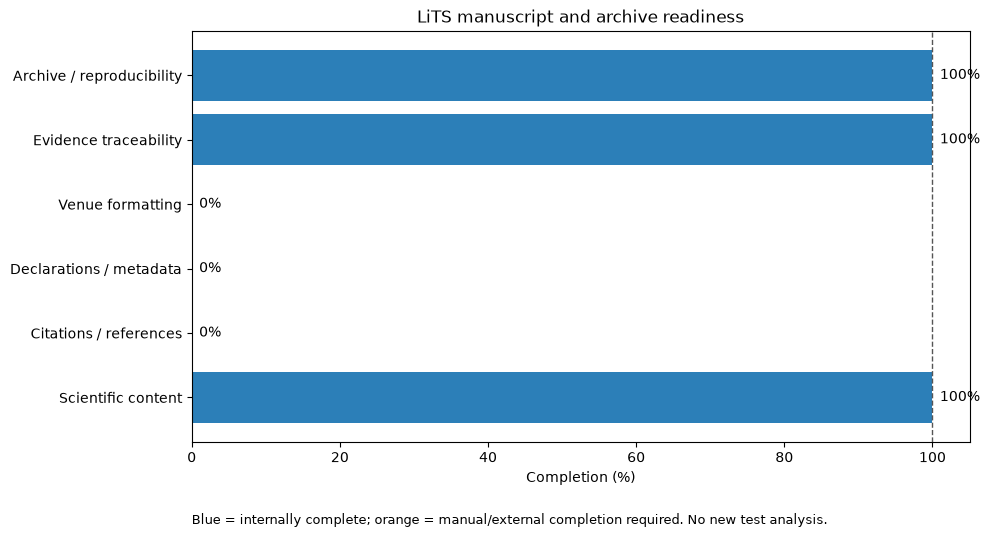

Result: DIAGNOSTIC_COMPLETE
Submission ready: False
Decision: COMPLETE_REFERENCES_DECLARATIONS_AND_VENUE_FORMATTING


In [5]:
category_rows=[]
for category,label in [("scientific_content","Scientific content"),("citations_references","Citations / references"),
 ("declarations_metadata","Declarations / metadata"),("venue_formatting","Venue formatting")]:
    d=checklist[checklist.category.eq(category)]
    category_rows.append((label,100*d.complete.mean(),int(d.complete.sum()),len(d)))
category_rows.extend([("Evidence traceability",100.0,len(claims_df),len(claims_df)),
                      ("Archive / reproducibility",100.0,int(verification.passed.sum()),len(verification))])
readiness=pd.DataFrame(category_rows,columns=["category","completion_pct","complete_items","total_items"])

fig,ax=plt.subplots(figsize=(10,5.5))
colors=["#2c7fb8" if v==100 else "#f28e2b" for v in readiness.completion_pct]
bars=ax.barh(readiness.category,readiness.completion_pct,color=colors)
ax.set_xlim(0,105); ax.set_xlabel("Completion (%)"); ax.set_title("LiTS manuscript and archive readiness")
ax.axvline(100,color="#555",lw=1,ls="--")
for b,v in zip(bars,readiness.completion_pct): ax.text(min(v+1,101),b.get_y()+b.get_height()/2,f"{v:.0f}%",va="center")
ax.text(0,-0.20,"Blue = internally complete; orange = manual/external completion required. No new test analysis.",transform=ax.transAxes,fontsize=9)
fig.tight_layout(); fig.savefig(OUT/"submission_readiness_dashboard.png",dpi=180,bbox_inches="tight"); plt.show(); plt.close(fig)

submission_ready=bool(checklist.loc[checklist.required_for_submission,"complete"].all())
actions=checklist.loc[~checklist.complete,["category","item","evidence_or_action"]].copy()
action_md=["# Manuscript Completion Actions","","Complete these items without reopening or reusing the test split:",""]
for i,r in enumerate(actions.itertuples(index=False),1): action_md.append(f"{i}. **{r.item}** — {r.evidence_or_action}")
action_md += ["","Any future model development must be a separately versioned study with a new untouched evaluation cohort."]
(OUT/"MANUSCRIPT_COMPLETION_ACTIONS.md").write_text("\n".join(action_md)+"\n",encoding="utf-8")

report_md=f'''# Submission Readiness Report

## Outcome

The artifact-only audit completed successfully, but the manuscript is **not yet submission-ready**. The scientific narrative, sealed evidence traceability, archive integrity and reproducibility records are complete. Manual and external items remain: literature references, author/institutional declarations, dataset terms confirmation, public availability decisions, target-venue selection and formatting, and an applicable reporting-guideline mapping.

## Scientific status

- Final package: `FINAL_PROJECT_COMPLETE`.
- Formal model acceptance: **failed** (7/8 targets; V121 minimum-patient Dice guardrail failed).
- Global Dice: {s5_gate['selected_metrics']['global_dice']:.6f}.
- Mean positive-patient Dice: {s5_gate['selected_metrics']['mean_positive_patient_dice']:.6f}.
- One-time test run: `{EXPECTED_RUN_ID}`; ledger complete and rerun prohibited.

## Audit status

- Sealed-package checks: {int(verification.passed.sum())}/{len(verification)} passed.
- Claims mapped to evidence: {len(claims_df)}/{len(claims_df)}.
- Archive inventory: {summary['file_count']} files with SHA-256 hashes.
- Submission-ready: **{str(submission_ready).lower()}**.

This audit did not access test images, masks, source files or statistics beyond already-generated sealed Part 2 artifacts, and did not rerun inference.
'''
(OUT/"SUBMISSION_READINESS_REPORT.md").write_text(report_md,encoding="utf-8")

archive_md=f'''# Part 2 Archive Readme

This archive records the completed LiTS Part 2 workflow through Step 05. `archive_manifest.csv` contains SHA-256 hashes for {summary['file_count']} contracts, code files, reports, tables, figures and machine-readable gates ({summary['total_bytes']} bytes). Step 06 is excluded to avoid circular self-signing. {summary['excluded_bulky_cache_or_model_files']} bulky cache/model files are not re-hashed here; their integrity remains covered by the signed Step 03–05 evidence inventories.

Authoritative outcome: final research package complete; formal model acceptance failed; one-time test run sealed; no further test use permitted.

Use `document_version_register.csv` for the principal report, manuscript, data card, reproducibility, gate and status documents. Verify any restored file by recomputing SHA-256 and comparing it with `archive_manifest.csv`.
'''
(OUT/"ARCHIVE_README.md").write_text(archive_md,encoding="utf-8")

configuration={"phase":"step_06_manuscript_submission_readiness_and_archive","created_utc":CREATED_UTC,
 "mode":"artifact_only_no_test_source_access","manifest_sha256":MANIFEST_SHA256,"source_test_run_id":EXPECTED_RUN_ID,
 "archive_scope":"Part 2 contracts and non-bulky Steps 01-05 deliverables; bulky binaries rely on signed source inventories","submission_ready_rule":"all required checklist items complete"}
provenance={"created_utc":CREATED_UTC,"source_step05_gate_sha256":sha256(S5/"gate_result.json"),
 "source_step05_signature_sha256":sha256(S5/"final_package_signature.json"),"source_step04_ledger_sha256":sha256(S4/"run_ledger.json"),
 "test_images_accessed":False,"test_source_files_reopened":False,"test_inference_rerun":False,
 "external_literature_or_venue_rules_queried":False}
save_json(configuration,"configuration.json"); save_json(provenance,"provenance.json")

requirements={"sealed_package_verified":bool(verification.passed.all()),"scientific_content_complete":bool(checklist.query("category=='scientific_content'").complete.all()),
 "claims_traceable":bool(claims_df.status.eq("verified").all()),"archive_inventory_complete":summary["unique_paths"] and summary["sha256_complete"],
 "readiness_report_saved":(OUT/"SUBMISSION_READINESS_REPORT.md").is_file(),"completion_actions_saved":(OUT/"MANUSCRIPT_COMPLETION_ACTIONS.md").is_file(),
 "test_inference_rerun_false":True,"test_source_files_reopened_false":True}
expected=pd.DataFrame([{"requirement":k,"expected":True,"actual":bool(v),"passed":bool(v)} for k,v in requirements.items()])
save_csv(expected,"expected_vs_actual.csv")
assert expected.passed.all()

gate={"status":"submission_readiness_audit_complete","result_level":"DIAGNOSTIC_COMPLETE","all_mandatory_targets_passed":True,
 "submission_ready":submission_ready,"decision":"COMPLETE_REFERENCES_DECLARATIONS_AND_VENUE_FORMATTING",
 "next_step":"manual_manuscript_completion_and_external_reference_review","formal_model_acceptance_passed":False,
 "formal_model_acceptance_failure":"minimum_positive_patient_dice","manifest_sha256":MANIFEST_SHA256,
 "source_test_run_id":EXPECTED_RUN_ID,"targets":requirements,"target_passes":requirements,
 "remaining_submission_items":actions['item'].tolist(),"archive_file_count":summary['file_count'],
 "test_images_accessed":False,"test_source_files_reopened":False,"test_inference_rerun":False}
save_json(gate,"gate_result.json")

signature_inputs=[OUT/"archive_manifest.csv",S5/"gate_result.json",S5/"final_package_signature.json",paper_path,report_path,OUT/"gate_result.json"]
signature={"algorithm":"SHA-256","created_utc":CREATED_UTC,"source_test_run_id":EXPECTED_RUN_ID,
 "formal_model_acceptance_passed":False,"submission_ready":submission_ready,"test_inference_rerun":False,"test_source_files_reopened":False,
 "signed_artifacts":{p.relative_to(PART2).as_posix():sha256(p) for p in signature_inputs}}
signature["combined_sha256"]=hashlib.sha256("".join(signature["signed_artifacts"].values()).encode()).hexdigest()
save_json(signature,"final_archive_signature.json")
print("Result: DIAGNOSTIC_COMPLETE")
print("Submission ready:",submission_ready)
print("Decision:",gate["decision"])

## Interpretation

The workflow is scientifically closed and archived. The next action is manual manuscript completion and an external reference/venue review—not another modeling or test-evaluation phase. The locked test split must remain untouched.